Understanding the Business Problem

# 1. Problem Statement and Basic Metrics

## Problem Statement

Analyze Netflix's content catalog to identify patterns in content type, countries, genres, ratings, release years, actors, directors and duration. These insights can help Netflix understand its existing content mix and make data-driven decisions about the types of content to produce and opportunities for growth across different countries.

## Business Questions

1. What type of content dominates Netflix?
2. How has content changed over time?
3. What types of content are available across countries?
4. Which genres and ratings dominate?
5. How does the Movie vs TV Show mix differ across countries?
6. Is Netflix increasingly adding TV Shows in recent years?
7. Which months have historically seen the most TV Show additions?

## Basic Metrics

Dataset size:
8,807 rows × 12 columns

Unique titles:
8,807

Content type:
Movies: 6,131 (69.6%)
TV Shows: 2,676 (30.4%)

Release year:
1925–2021
Median: 2017

Duplicate titles:
0

Data Understanding & Data Quality Audit

In [1]:
import numpy as np
import pandas as pd

url='https://raw.githubusercontent.com/Gokulprasanth26/Netflix-Data-Analysis/refs/heads/main/netflix.csv'
df=pd.read_csv(url)
df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5616,s5617,Movie,Dilwale,Rohit Shetty,"Shah Rukh Khan, Kajol, Kriti Sanon, Kabir Bedi...",India,"February 1, 2017",2015,TV-PG,154 min,"Action & Adventure, Dramas, International Movies","A young couple falls in love, but conflicting ..."
1160,s1161,Movie,Croupier,Mike Hodges,"Clive Owen, Kate Hardie, Alex Kingston, Gina M...","Ireland, United Kingdom, France, Germany","March 26, 2021",1998,TV-MA,95 min,"Dramas, Independent Movies, Thrillers",A would-be writer lands a job as a croupier to...
7489,s7490,Movie,Monster High 13 Wishes,Steve Sacks,"Erin Fitzgerald, Missi Hale, Marcus Griffin, C...",United States,"March 1, 2018",2013,TV-Y7,73 min,Children & Family Movies,"It's a new school year at Monster High, and th..."
6756,s6757,Movie,Fire at Sea,Gianfranco Rosi,"Samuele Caruana, Giuseppe Fragapane","Italy, France","March 21, 2017",2016,TV-14,114 min,"Documentaries, International Movies","Heartbreak, hope and nostalgia collide in this..."
167,s168,Movie,Open Season 2,"Matthew O'Callaghan, Todd Wilderman","Joel McHale, Mike Epps, Jane Krakowski, Billy ...","United States, Canada","September 1, 2021",2008,PG,76 min,"Children & Family Movies, Comedies",Elliot the buck and his forest-dwelling cohort...
5484,s5485,Movie,Natascha Kampusch: The Whole Story,Alina Teodorescu,NaN,United States,"May 15, 2017",2010,TV-14,51 min,Movies,A Viennese child who was kidnapped and held ca...
4609,s4610,Movie,Tiger,Sartaj Singh Pannu,"Sippy Gill, Ihana Dhillon, Yograj Singh, Yashp...",India,"October 1, 2018",2016,TV-14,130 min,"Action & Adventure, Dramas, International Movies","Imprisoned for drug smuggling as a child, a yo..."
5090,s5091,TV Show,Episodes,NaN,"Matt LeBlanc, Tamsin Greig, Stephen Mangan, Ka...","United Kingdom, United States","January 6, 2018",2017,TV-MA,5 Seasons,"Classic & Cult TV, TV Comedies",Hoping to create an American version of their ...
6834,s6835,TV Show,Genius of the Ancient World,NaN,Bettany Hughes,United Kingdom,"August 1, 2017",2015,TV-PG,1 Season,"British TV Shows, Docuseries, International TV...","Historian Bettany Hughes travels to India, Gre..."
4263,s4264,TV Show,Demon's Path,NaN,"Wai Ai, Jim Chim Sui Man, Kwok-Pong Chan, Feli...",NaN,"December 22, 2018",2018,TV-14,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","To catch three criminal masterminds, a group o..."


In [2]:
df.shape

(8807, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing-value range before cleaning:

`director` is the worst offender at 2,634 nulls (29.9% of rows), followed by `cast` (825, 9.4%) and `country` (831, 9.4%). `date_added`, `rating`, and `duration` were negligible (≤10 rows each).

In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [7]:
df['title'].duplicated().sum()

0

In [8]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [9]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Unnesting Director and Cast column and cleaning

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [11]:
df['director'] = df['director'].str.strip()
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [12]:
df['cast'] = df['cast'].fillna('Unknown')
df['cast'] = df['cast'].str.strip()
df['cast'].head()

0                                              Unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              Unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
Name: cast, dtype: object

In [13]:
df_clean=df.copy() 

df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['director'] = df_clean['director'].str.strip()
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [14]:
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].str.strip()
df_clean['cast'].head(10)

0                                              Unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              Unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5    Kate Siegel, Zach Gilford, Hamish Linklater, H...
6    Vanessa Hudgens, Kimiko Glenn, James Marsden, ...
7    Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...
8    Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...
9    Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...
Name: cast, dtype: object

In [15]:
df_clean[['director','cast']].isna().sum()

director    0
cast        0
dtype: int64

In [16]:
categorical_cols = ['type', 'rating']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

In [17]:
df_clean.dtypes

show_id           object
type            category
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
rating          category
duration          object
listed_in         object
description       object
dtype: object

In [18]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [19]:
#Splitting the director,cast column into an individual string list 
df_clean['director_list'] = df_clean['director'].str.split(',')
#"Robert Cullen, José Luis Ucha" converts to two string "Robert Cullen "," José Luis Ucha"
df_clean['cast_list'] = df_clean['cast'].str.split(',')
df_clean[['title','director','director_list','cast_list']].head(10)

,title,director,director_list,cast_list
0,Dick Johnson Is Dead,Kirsten Johnson,[Kirsten Johnson],[Unknown]
1,Blood & Water,Unknown,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th..."
2,Ganglands,Julien Leclercq,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ..."
3,Jailbirds New Orleans,Unknown,[Unknown],[Unknown]
4,Kota Factory,Unknown,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Al..."
5,Midnight Mass,Mike Flanagan,[Mike Flanagan],"[Kate Siegel, Zach Gilford, Hamish Linklater..."
6,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","[Robert Cullen, José Luis Ucha]","[Vanessa Hudgens, Kimiko Glenn, James Marsde..."
7,Sankofa,Haile Gerima,[Haile Gerima],"[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandr..."
8,The Great British Baking Show,Andy Devonshire,[Andy Devonshire],"[Mel Giedroyc, Sue Perkins, Mary Berry, Pau..."
9,The Starling,Theodore Melfi,[Theodore Melfi],"[Melissa McCarthy, Chris O'Dowd, Kevin Kline..."


In [20]:
#Cleans the spaces in the director_list and cast_list columns
df_clean['director_list'] = df_clean['director_list'].apply(lambda x:[name.strip() for name in x])
#"Robert Cullen "," José Luis Ucha" converts to "Robert Cullen","José Luis Ucha" uses for loop to check individual string her in this as Robert Cullen,José Luis Ucha
df_clean['cast_list'] = df_clean['cast_list'].apply(lambda x:[name.strip() for name in x])
df_clean[['title','director_list','cast_list']].head(10)

,title,director_list,cast_list
0,Dick Johnson Is Dead,[Kirsten Johnson],[Unknown]
1,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba..."
2,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab..."
3,Jailbirds New Orleans,[Unknown],[Unknown]
4,Kota Factory,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ..."
5,Midnight Mass,[Mike Flanagan],"[Kate Siegel, Zach Gilford, Hamish Linklater, ..."
6,My Little Pony: A New Generation,"[Robert Cullen, José Luis Ucha]","[Vanessa Hudgens, Kimiko Glenn, James Marsden,..."
7,Sankofa,[Haile Gerima],"[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra ..."
8,The Great British Baking Show,[Andy Devonshire],"[Mel Giedroyc, Sue Perkins, Mary Berry, Paul H..."
9,The Starling,[Theodore Melfi],"[Melissa McCarthy, Chris O'Dowd, Kevin Kline, ..."


In [21]:
title_cast = df_clean[['show_id', 'title', 'cast_list']].explode('cast_list')
title_cast = title_cast.rename(columns={'cast_list':'cast_member'})
title_cast.head()

,show_id,title,cast_member
0,s1,Dick Johnson Is Dead,Unknown
1,s2,Blood & Water,Ama Qamata
1,s2,Blood & Water,Khosi Ngema
1,s2,Blood & Water,Gail Mabalane
1,s2,Blood & Water,Thabang Molaba


In [22]:
title_director = df_clean[['show_id','title','director_list']].explode('director_list')
title_director = title_director.rename(columns={'director_list':'director'})
title_director.head()

,show_id,title,director
0,s1,Dick Johnson Is Dead,Kirsten Johnson
1,s2,Blood & Water,Unknown
2,s3,Ganglands,Julien Leclercq
3,s4,Jailbirds New Orleans,Unknown
4,s5,Kota Factory,Unknown


In [23]:
title_director['director'].value_counts().head(10)

director
Unknown                2634
Rajiv Chilaka            22
Jan Suter                21
Raúl Campos              19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Martin Scorsese          12
Jay Chapman              12
Name: count, dtype: int64

In [24]:
title_cast['cast_member'].value_counts().head(10)

cast_member
Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64

In [25]:
print(df_clean.shape)
print(title_director.shape)
print(title_cast.shape)

(8807, 14)
(9612, 3)
(64951, 3)


In [26]:
#We are filtering only the rows where the director is not 'Unknown',by preserving it instead of dropping it, we can use it for analysis later on. The same is done for the cast_member column.
title_director = title_director[title_director['director'] != 'Unknown']
title_cast = title_cast[title_cast['cast_member'] != 'Unknown']


In [27]:
print(df_clean.shape)
print(title_director.shape)
print(title_cast.shape)

(8807, 14)
(6978, 3)
(64126, 3)


In [28]:
#Checking for duplicates in the cast and director columns
title_cast.duplicated(subset=['show_id','cast_member']).sum()

2

In [29]:
title_cast[title_cast.duplicated(subset=['show_id','cast_member'],keep=False)]

,show_id,title,cast_member
1631,s1632,Rust Creek,Micah Hauptman
1631,s1632,Rust Creek,Micah Hauptman
6013,s6014,300 Miles to Heaven,Adrianna Biedrzyńska
6013,s6014,300 Miles to Heaven,Adrianna Biedrzyńska


In [30]:
title_director.duplicated(subset=['show_id','director']).sum()

1

In [31]:
title_director[title_director.duplicated(subset=['show_id','director'],keep=False)]

,show_id,title,director
3718,s3719,Blood Will Tell,Miguel Cohan
3718,s3719,Blood Will Tell,Miguel Cohan


In [32]:
#Check the main data for the duplicates
df_clean[df_clean['show_id']== 's3719'][['title','director']]


,title,director
3718,Blood Will Tell,"Miguel Cohan, Miguel Cohan"


In [33]:
#Dropping the duplicates in the cast and director columns
title_cast = title_cast.drop_duplicates(subset=['show_id','cast_member'])
title_director = title_director.drop_duplicates(subset=['show_id', 'director'])

title_cast.duplicated(subset=['show_id','cast_member']).sum()
title_director.duplicated(subset=['show_id','director']).sum()

0

Country column cleaning

In [34]:
df_clean['country'].isna().sum()

831

In [35]:
#Country column
# Fill NaN/Null values to Unknown
df_clean['country'] = df_clean['country'].fillna('Unknown')  
df_clean['country_list'] = df_clean['country'].str.split(',')
df_clean['country_list'] = df_clean['country_list'].apply(lambda x: [country.strip() for country in x])
title_country = df_clean[['show_id','title','country_list']].explode('country_list')
title_country = title_country.rename(columns={'country_list':'country'})
title_country = title_country[title_country['country'] != 'Unknown']
title_country.head(15)


,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
4,s5,Kota Factory,India
7,s8,Sankofa,United States
7,s8,Sankofa,Ghana
7,s8,Sankofa,Burkina Faso
7,s8,Sankofa,United Kingdom
7,s8,Sankofa,Germany
7,s8,Sankofa,Ethiopia
8,s9,The Great British Baking Show,United Kingdom


Listed_in column cleaning

In [36]:
#Clean 'listed_in' column  
df_clean['listed_in'] = df_clean['listed_in'].fillna('Unknown')
df_clean['genre_list'] = df_clean['listed_in'].str.split(',')
df_clean['genre_list'] = df_clean['genre_list'].apply(lambda x: [genre.strip() for genre in x])

title_genre = df_clean[['show_id','title','genre_list']].explode('genre_list')
title_genre.rename(columns={'genre_list':'genre'},inplace=True)
title_genre.head(10)

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows
2,s3,Ganglands,International TV Shows
2,s3,Ganglands,TV Action & Adventure
3,s4,Jailbirds New Orleans,Docuseries
3,s4,Jailbirds New Orleans,Reality TV
4,s5,Kota Factory,International TV Shows


Date_added column cleaning

In [37]:
# df_clean['date_added'] = df_clean['date_added'].fillna('Unknown')
#error shows 'NaT' Not a Time when "errors='coerce'" is used, if "errors='coerce'" not used then it fails
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')
df_clean['date_added'].head(20)

0    2021-09-25
1    2021-09-24
2    2021-09-24
3    2021-09-24
4    2021-09-24
5    2021-09-24
6    2021-09-24
7    2021-09-24
8    2021-09-24
9    2021-09-24
10   2021-09-24
11   2021-09-23
12   2021-09-23
13   2021-09-22
14   2021-09-22
15   2021-09-22
16   2021-09-22
17   2021-09-22
18   2021-09-22
19   2021-09-22
Name: date_added, dtype: datetime64[ns]

In [38]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   category      
 2   title          8807 non-null   object        
 3   director       8807 non-null   object        
 4   cast           8807 non-null   object        
 5   country        8807 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8803 non-null   category      
 9   duration       8804 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  director_list  8807 non-null   object        
 13  cast_list      8807 non-null   object        
 14  country_list   8807 non-null   object        
 15  genre_list     8807 n

In [39]:
df_clean['added_year'] = df_clean['date_added'].dt.year
df_clean['added_month'] = df_clean['date_added'].dt.month 
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name()

In [40]:
df_clean.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0,September


Duration column cleaning

In [41]:
#clean 'duration' column
df_clean['movie_duration_min'] = np.where(
    df_clean['type'] == 'Movie',
    df_clean['duration'].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)

df_clean['tv_seasons'] = np.where(
    df_clean['type'] == 'TV Show',
    df_clean['duration'].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)

Rating column cleaning

In [42]:
#clean rating column
df_clean['rating'] = df['rating'].fillna('Unknown')

In [43]:
df_clean.isna().sum()

show_id                  0
type                     0
title                    0
director                 0
cast                     0
country                  0
date_added              10
release_year             0
rating                   0
duration                 3
listed_in                0
description              0
director_list            0
cast_list                0
country_list             0
genre_list               0
added_year              10
added_month             10
added_month_name        10
movie_duration_min    2679
tv_seasons            6131
dtype: int64

In [44]:
print(df_clean.shape)
print(title_cast.shape)
print(title_director.shape)
print(title_country.shape)
print(title_genre.shape)

(8807, 21)
(64124, 3)
(6977, 3)
(10019, 3)
(19323, 3)


Visual Analysis

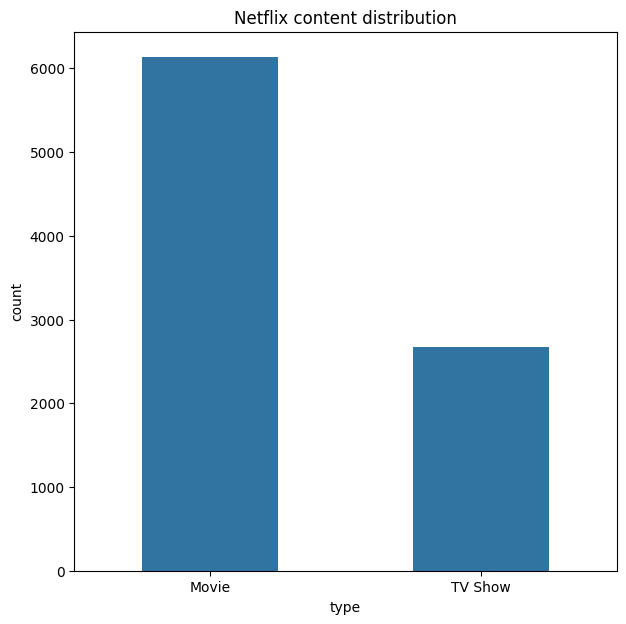

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

#Content distribution in Netflix 
plt.figure(figsize=(7,7))

sns.countplot(data=df_clean,x='type',width=0.5)

plt.title('Netflix content distribution')
plt.show()

#Netflix has more movies compared to TV Shows

In [46]:
content_percentage = (df_clean['type'].value_counts(normalize=True)*100)
content_percentage.round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

type:

69.62% Movies vs 30.38% TV Shows (6,131 vs 2,676). Any modeling or comparison done on this dataset needs to account for that imbalance.

added_year
2019.0    2016
2020.0    1879
2018.0    1649
2021.0    1498
2017.0    1188
2016.0     429
2015.0      82
2014.0      24
2011.0      13
2013.0      11
2012.0       3
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64


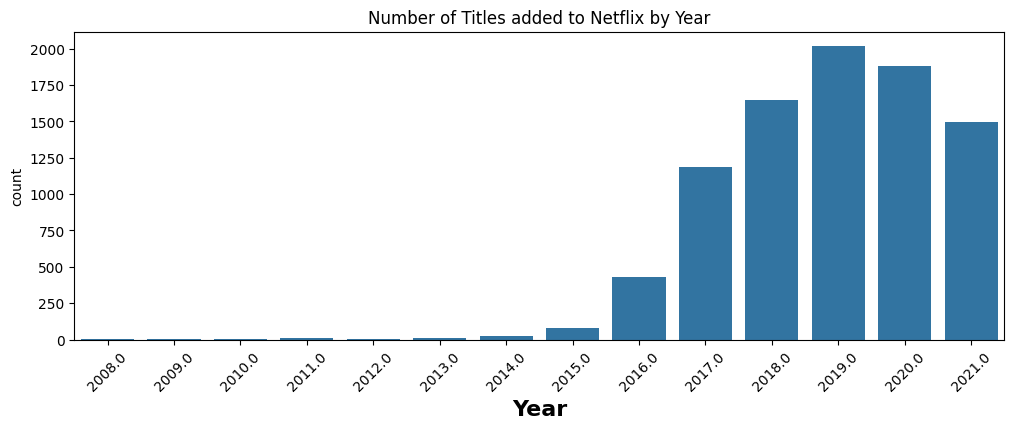

In [47]:
#Number of Titles added for each year to Netflix
print(df_clean['added_year'].value_counts())

plt.figure(figsize=(12,4))
sns.countplot(data=df_clean,x='added_year',order=sorted(df_clean['added_year'].dropna().unique()))
#dropna().unique() --> these removes the NaN from the xlabel

plt.title('Number of Titles added to Netflix by Year')
plt.xticks(rotation=45)
plt.xlabel('Year',fontdict={'fontsize':16,'fontweight':'bold'})
plt.show()

type        Movie  TV Show
added_year                
2008.0          1        1
2009.0          2        0
2010.0          1        0
2011.0         13        0
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


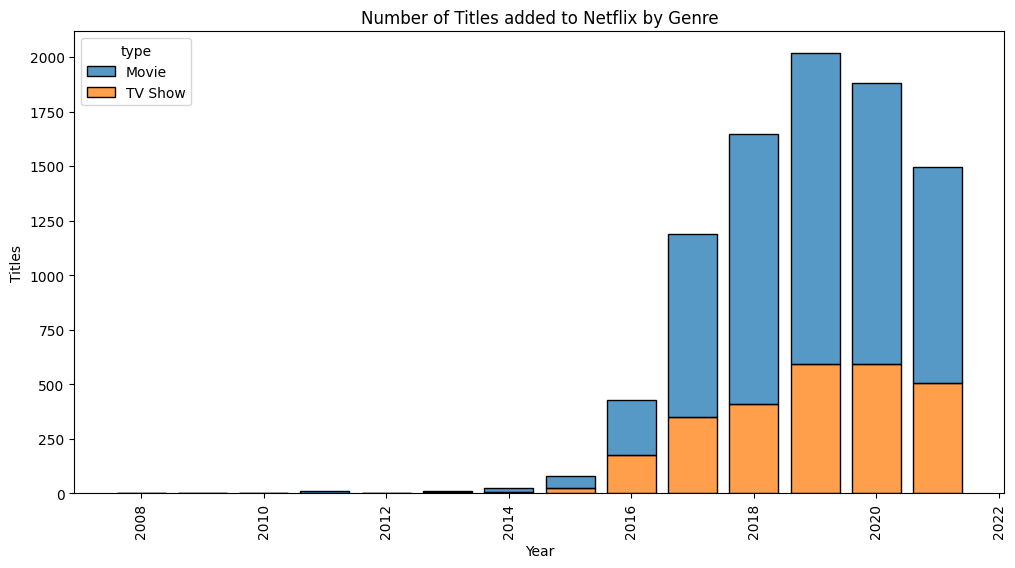

In [116]:
#Number of Title added to Netflix by year with genre
content_growth=pd.crosstab(df_clean['added_year'],df_clean['type'])

print(content_growth)

plt.figure(figsize=(12,6))
# content_growth.plot(kind='bar',figsize=(10,5),width=0.7)
# sns.countplot(data=df_clean, x='added_year', hue='type')
sns.histplot(data=df_clean, x='added_year', hue='type',multiple='stack',discrete=True,shrink=0.8)

plt.title('Number of Titles added to Netflix by Genre')
plt.xlabel('Year')
plt.xticks(rotation=90)
plt.ylabel('Titles')
plt.show()

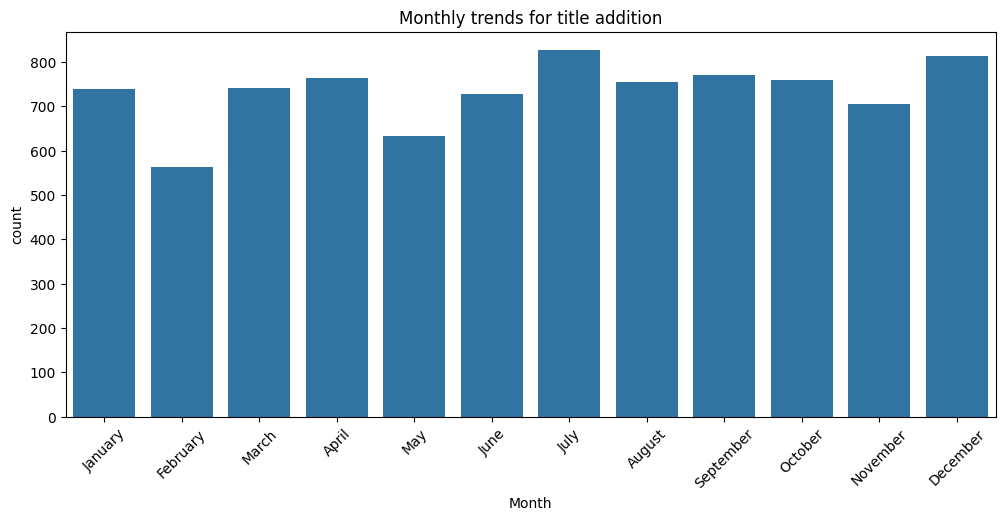

In [49]:
x=['January','February','March','April','May','June','July','August','September','October','November','December']

plt.figure(figsize=(12,5))
sns.countplot(data=df_clean,x='added_month_name',order=x)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Monthly trends for title addition')
plt.show()

In [50]:
#Top 10 country to contribute to Netflix
country_count = title_country['country'].value_counts(ascending=False)
country_count.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

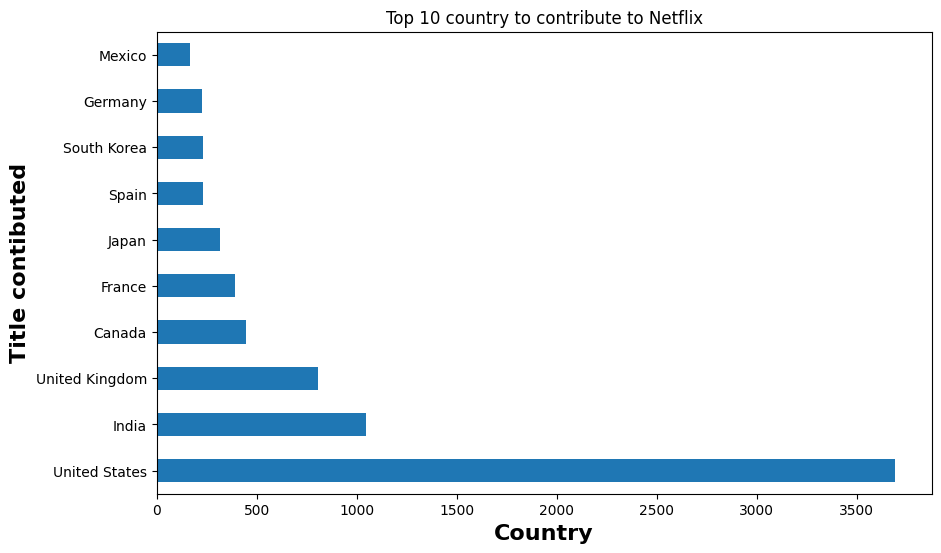

In [51]:
plt.figure(figsize=(10,6))


country_count.head(10).plot(kind='barh')

plt.title('Top 10 country to contribute to Netflix')
plt.xlabel('Country',fontdict={'fontsize':16,'fontweight':'bold'})
plt.ylabel('Title contibuted',fontdict={'fontsize':16,'fontweight':'bold'})
plt.show()

country:

country is heavily concentrated: the United States alone contributes 36.83% of all country-tags, and the top 10 countries together account for ~75% of all contributions, out of 61+ countries represented. Global reach is wide but shallow — most countries appear only a handful of times.

In [52]:
title_country.head()
df_clean.head()

#To fetch country we use title_country(the untangeld version of country done previously till explosion) and merge
country_type = title_country.merge(df_clean[['show_id','type']],on='show_id',how='left')
country_type.head()

,show_id,title,country,type
0,s1,Dick Johnson Is Dead,United States,Movie
1,s2,Blood & Water,South Africa,TV Show
2,s5,Kota Factory,India,TV Show
3,s8,Sankofa,United States,Movie
4,s8,Sankofa,Ghana,Movie


In [53]:
#As country and type are both "Categorical" data we use crosstab so we can have an idea on the variables before visualization
country_type_table = pd.crosstab(country_type['country'],country_type['type'])
country_type_table.index.name = None
country_type_table.columns.name = None
country_type_table.head(10)
#the first one in the table is blank as it represents NaN

,Movie,TV Show
,6,1
Afghanistan,1,0
Albania,1,0
Algeria,3,0
Angola,1,0
Argentina,71,20
Armenia,1,0
Australia,94,66
Austria,11,1
Azerbaijan,0,1


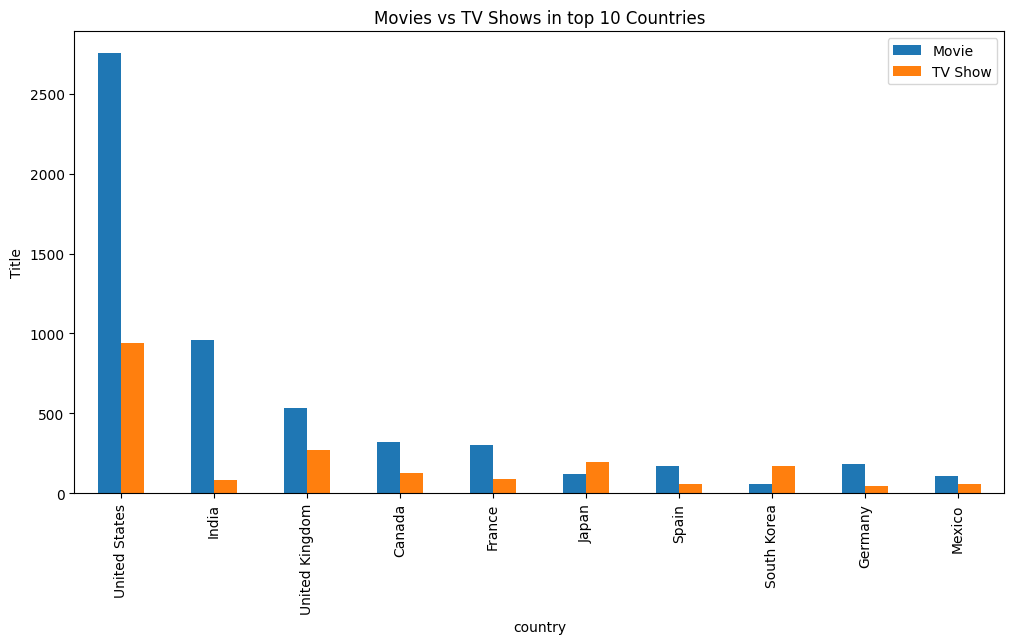

In [54]:
top10 = country_count.head(10).index

country_type_table.loc[top10].plot(kind='bar',figsize=(12,6))

plt.ylabel("Title")
plt.title("Movies vs TV Shows in top 10 Countries")
plt.show()

In [55]:
#Country diversification
country_percentage = title_country['country'].value_counts(normalize=True)*100
country_percentage.head(10)

country
United States     36.830023
India             10.440164
United Kingdom     8.044715
Canada             4.441561
France             3.922547
Japan              3.173969
Spain              2.315600
South Korea        2.305619
Germany            2.255714
Mexico             1.686795
Name: proportion, dtype: float64

In [56]:
diversed_content = country_type.groupby('country')['type'].nunique()
diversed_content[diversed_content==2]

country
                        2
Argentina               2
Australia               2
Austria                 2
Belgium                 2
                       ..
United Arab Emirates    2
United Kingdom          2
United States           2
Uruguay                 2
West Germany            2
Name: type, Length: 61, dtype: int64

In [57]:
country_type = title_country.merge(df_clean[['show_id','added_year']],on='show_id')
country_type.head()

,show_id,title,country,added_year
0,s1,Dick Johnson Is Dead,United States,2021.0
1,s2,Blood & Water,South Africa,2021.0
2,s5,Kota Factory,India,2021.0
3,s8,Sankofa,United States,2021.0
4,s8,Sankofa,Ghana,2021.0


<Figure size 2400x1200 with 0 Axes>

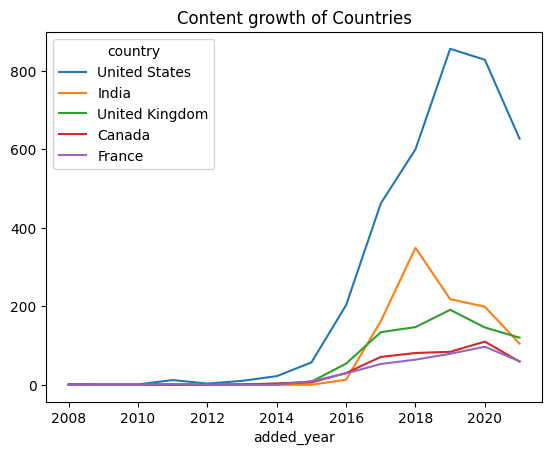

In [58]:
country_year = pd.crosstab(country_type['added_year'],country_type['country'])

top5=country_count.head(5).index

plt.figure(figsize=(12,6),dpi=200)

country_year[top5].plot()
plt.title('Content growth of Countries')
plt.show()

added_year:

added year shows a clear growth-then-plateau shape: additions rose every year from 2008, peaked in 2019 (2,016 titles added), then declined in 2020 (1,879) and fell further in 2021 (1,498) — a reversal, not just a slowdown.

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


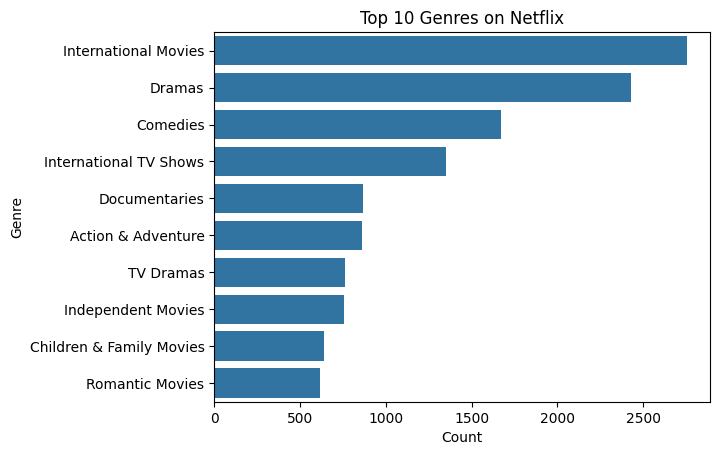

In [59]:
genre_count = title_genre['genre'].value_counts(ascending =False).head(10)

print(genre_count)

sns.barplot(x=genre_count.values,y=genre_count.index)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [60]:
genre_type = title_genre.merge(df_clean[['show_id','type']],on='show_id',how='left')
genre_type_table = pd.crosstab(genre_type['genre'],genre_type['type'])
genre_type_table.head()

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0


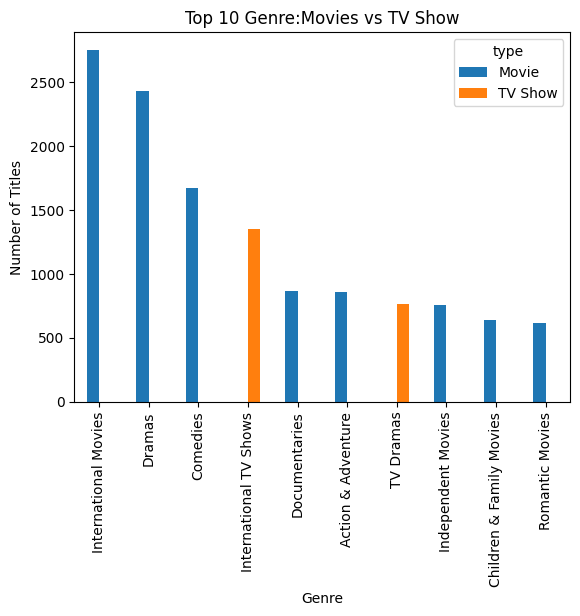

In [61]:
top_genres = genre_count.index

genre_type_table.loc[top_genres].plot(kind='bar')

plt.title('Top 10 Genre:Movies vs TV Show')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.show()

genre:

genre has 42 unique tags but is long-tailed: "International Movies" (2,752) and "Dramas" (2,427) are the two biggest single tags, and the top 10 genres dominate volume even though Movies alone span 20 distinct genres and TV Shows span 22.

In [62]:
#for movie
movie_genres = (genre_type[genre_type['type']=='Movie']['genre'].value_counts(ascending=False))
movie_genres.head()

#for Tv_show
tv_genres = genre_type[genre_type['type']=='TV Show']['genre'].value_counts(ascending=False)
tv_genres.head()

genre
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Name: count, dtype: int64

In [63]:
movie_genres.head()

genre
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

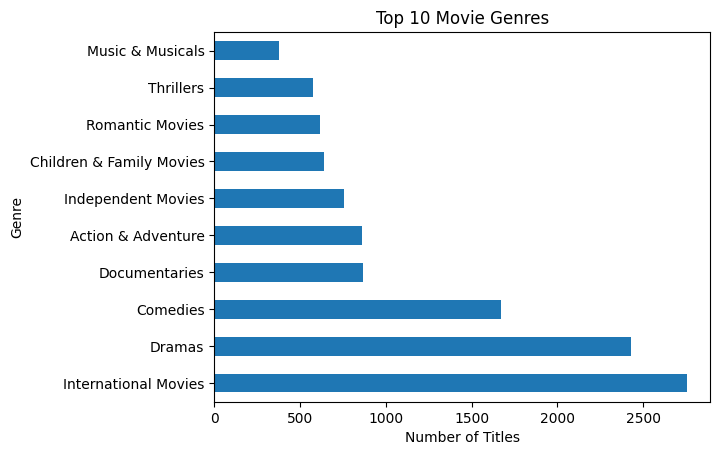

In [64]:
movie_genres.head(10).plot(kind='barh')

plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

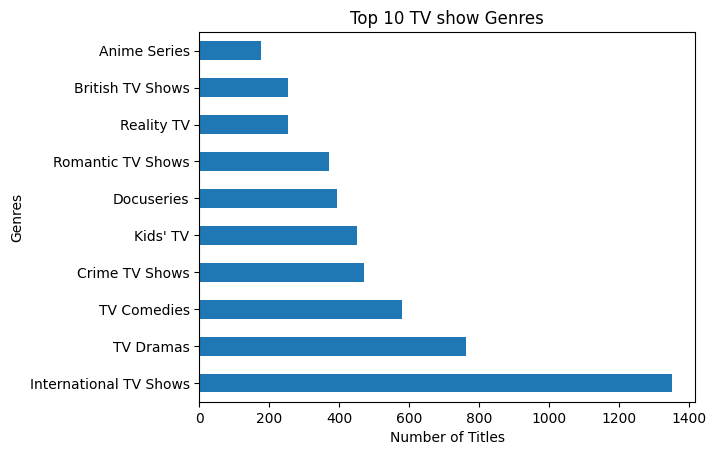

In [65]:
tv_genres.head(10).plot(kind='barh')

plt.title('Top 10 TV show Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.show()

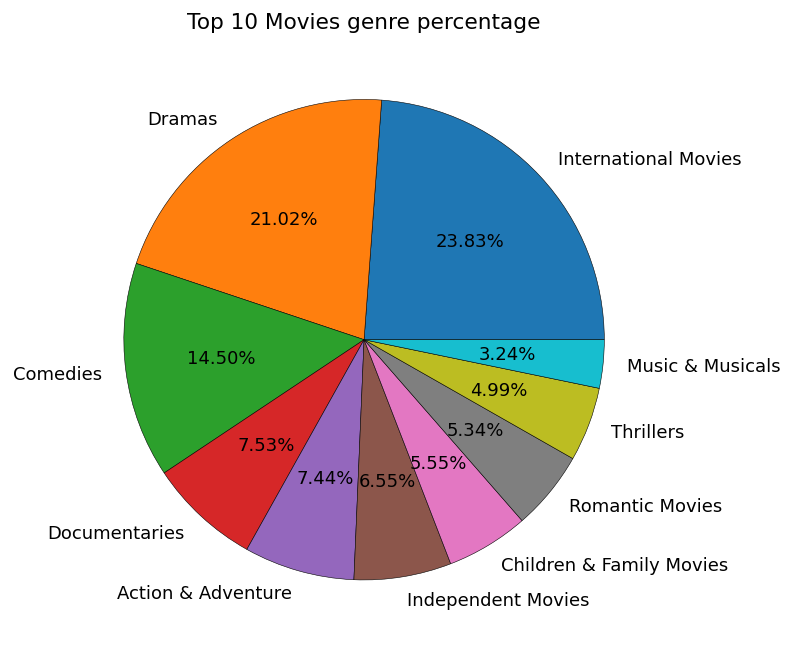

In [66]:
#Top 10 movies by Genre
movie_genre_percentage = round((movie_genres/movie_genres.sum())*100,2)
top10_movie_genre = movie_genre_percentage.head(10)

plt.figure(figsize=(12,6),dpi=130)
plt.pie(x=top10_movie_genre.values,labels=top10_movie_genre.index,autopct='%1.2f%%',wedgeprops={'edgecolor':'black','linewidth':0.3})
plt.title('Top 10 Movies genre percentage')
plt.show()

In [67]:
title_genre['genre'].nunique()

42

In [68]:
genre_type.groupby('type')['genre'].nunique()

C:\Users\GOKUL\AppData\Local\Temp\ipykernel_1700\3443491153.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_type.groupby('type')['genre'].nunique()


type
Movie      20
TV Show    22
Name: genre, dtype: int64

In [69]:
genre_year = title_genre.merge(df_clean[['show_id','added_year','added_month']],on='show_id',how='left')

top5_genres = (title_genre['genre'].value_counts().head(5).index)

genre_year_top5 = genre_year[genre_year['genre'].isin(top5_genres)]
genre_year_top5

genre_trend = pd.crosstab(genre_year_top5['added_year'],genre_year_top5['genre'])
genre_trend.head()


genre,Comedies,Documentaries,Dramas,International Movies,International TV Shows
added_year,,,,,
2008.0,0,0,1,0,0
2009.0,0,0,1,1,0
2011.0,0,0,13,1,0
2012.0,2,1,0,0,0
2013.0,1,1,0,0,1


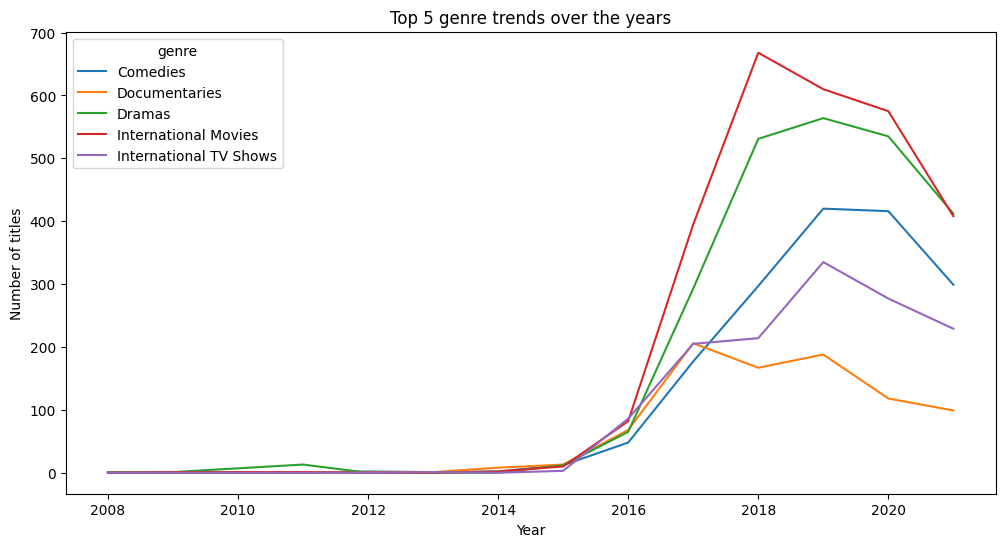

In [70]:
genre_trend.plot(kind='line',figsize=(12,6))
plt.title('Top 5 genre trends over the years')
plt.xlabel('Year')
plt.ylabel('Number of titles')
plt.show()

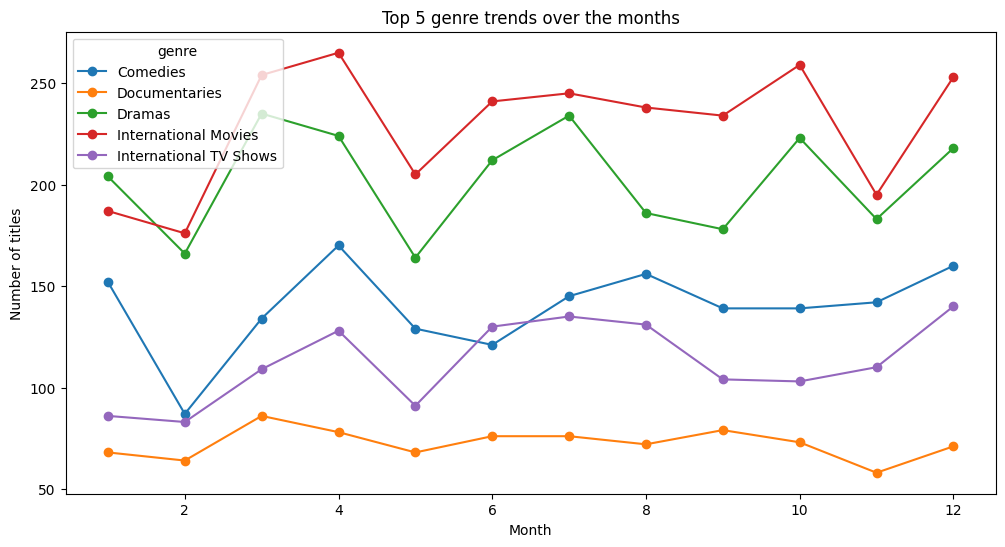

In [71]:
top5_genres = (title_genre['genre'].value_counts().head(5).index)
top5_genres

genre_month_top5 = genre_year[genre_year['genre'].isin(top5_genres)]
genre_month_top5

genre_trend = pd.crosstab(genre_month_top5['added_month'],genre_month_top5['genre'])
genre_trend.head()

genre_trend.plot(kind='line',figsize=(12,6),marker='o')
plt.title('Top 5 genre trends over the months')
plt.xlabel('Month')
plt.ylabel('Number of titles')
plt.show()

In [72]:
title_genre.duplicated(
    subset=['show_id', 'genre']
).sum()

#no duplicated data is good

0

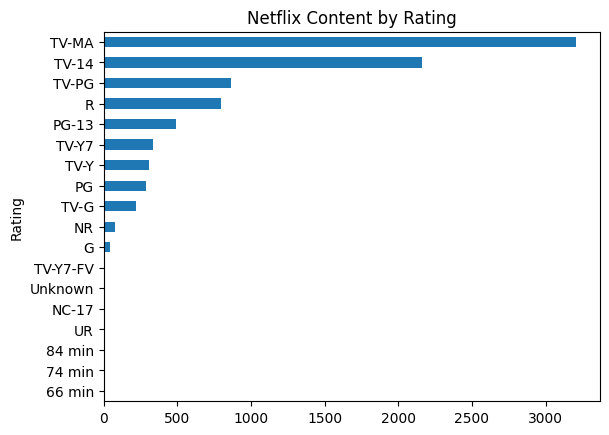

In [73]:
#Rating column
rating_count = df_clean['rating'].value_counts(dropna=False)
rating_count.head()

rating_count.sort_values().plot(kind='barh')
plt.title('Netflix Content by Rating')
plt.ylabel('Rating')
plt.show()

In [118]:
df_clean['rating'].value_counts().head(5)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

In [122]:
df_clean['rating'].value_counts(normalize=True)*100

rating
TV-MA       36.414216
TV-14       24.525945
TV-PG        9.799024
R            9.072329
PG-13        5.563756
TV-Y7        3.792438
TV-Y         3.485864
PG           3.258771
TV-G         2.498013
NR           0.908368
G            0.465539
TV-Y7-FV     0.068128
Unknown      0.045418
NC-17        0.034064
UR           0.034064
74 min       0.011355
84 min       0.011355
66 min       0.011355
Name: proportion, dtype: float64

rating:

rating is skewed toward mature audiences: TV-MA alone is 3,207 titles — the single largest rating bucket — and TV-MA + TV-14 together account for well over 60% of the whole catalog.

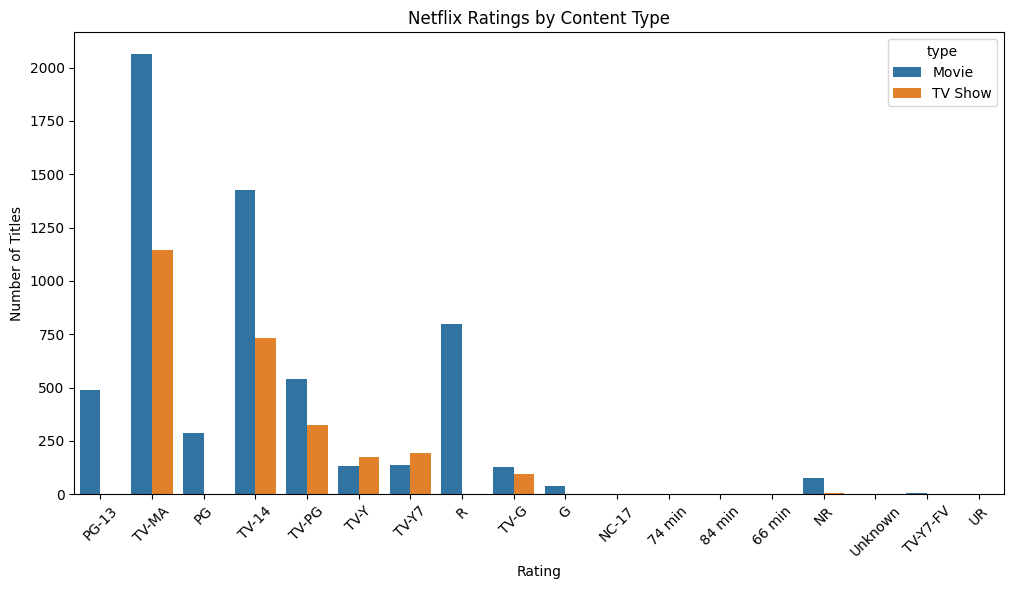

In [74]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean,x='rating',hue='type')

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='type'>

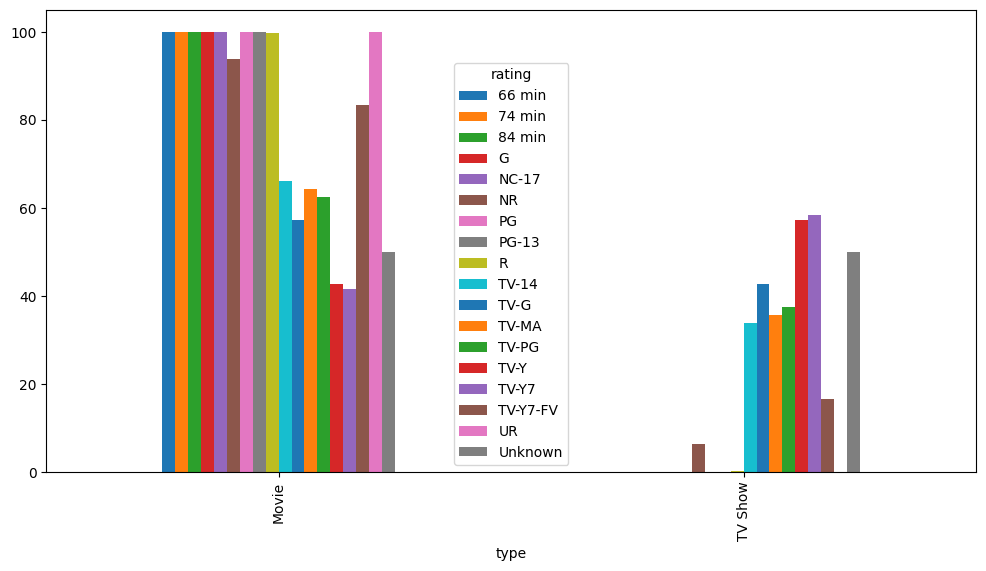

In [75]:
rating_type = pd.crosstab(df_clean['rating'],df_clean['type'])

rating_type_percentage = pd.crosstab(df_clean['rating'],df_clean['type'],normalize='index')*100
rating_type_percentage

rating_type_percentage.T.plot(kind='bar',figsize=(12,6))

In [76]:
movie_rating = df_clean[df_clean['type']=='Movie']['rating'].value_counts(normalize=True)*100
movie_rating.head(5)



rating
TV-MA    33.632360
TV-14    23.275159
R        12.999511
TV-PG     8.807699
PG-13     7.992171
Name: proportion, dtype: float64

In [77]:
tv_show_rating = df_clean[df_clean['type']=='TV Show']['rating'].value_counts(normalize=True)*100
tv_show_rating.head(3)

rating
TV-MA    42.787743
TV-14    27.391629
TV-PG    12.070254
Name: proportion, dtype: float64

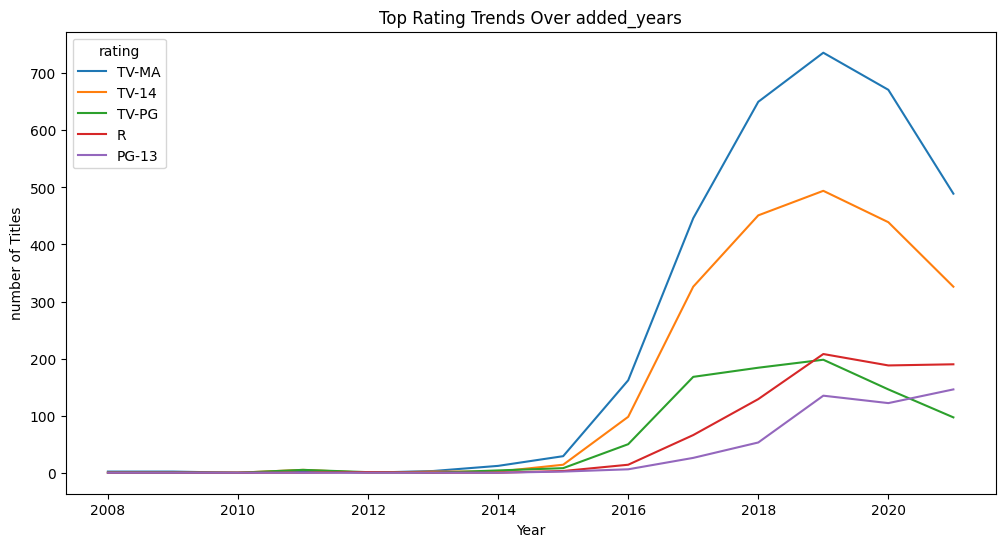

In [78]:
rating_year = pd.crosstab(df_clean['added_year'],df_clean['rating'])
rating_year


top_ratings = df_clean['rating'].value_counts().head(5).index

rating_trend = rating_year[top_ratings]
rating_trend

rating_trend.plot(kind='line',figsize=(12,6))

plt.title('Top Rating Trends Over added_years')
plt.xlabel('Year')
plt.ylabel('number of Titles')
plt.show()

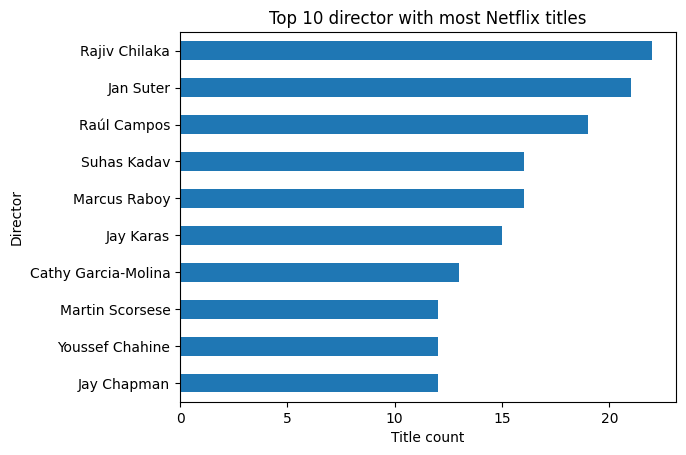

In [79]:
director_count = title_director['director'].value_counts().head(10)

director_count.sort_values().plot(kind='barh')
plt.title('Top 10 director with most Netflix titles')
plt.xlabel('Title count')
plt.ylabel('Director')
plt.show()

In [80]:
#No duplicates found
title_director.duplicated(subset=['show_id','director']).sum()

0

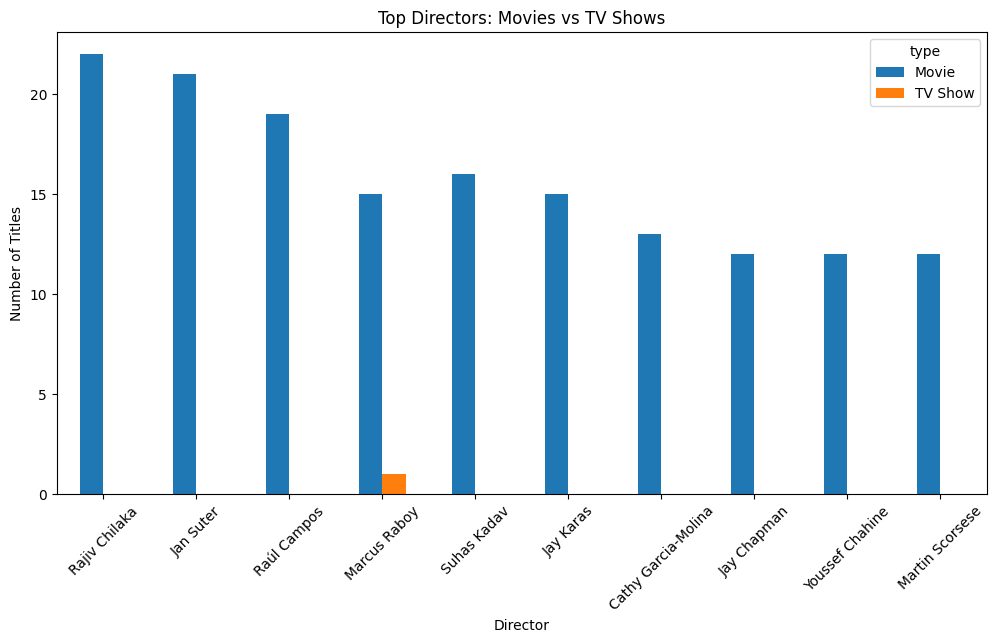

In [81]:
director_type = title_director.merge(df_clean[['show_id','type']],on='show_id',how='left')
director_type.head()

director_type_table  = pd.crosstab(director_type['director'],director_type['type'])
top_directors = director_count.head(10).index
top_directors

director_type_table.loc[top_directors].plot(kind='bar',figsize=(12,6))

plt.title('Top Directors: Movies vs TV Shows')
plt.xlabel('Director')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

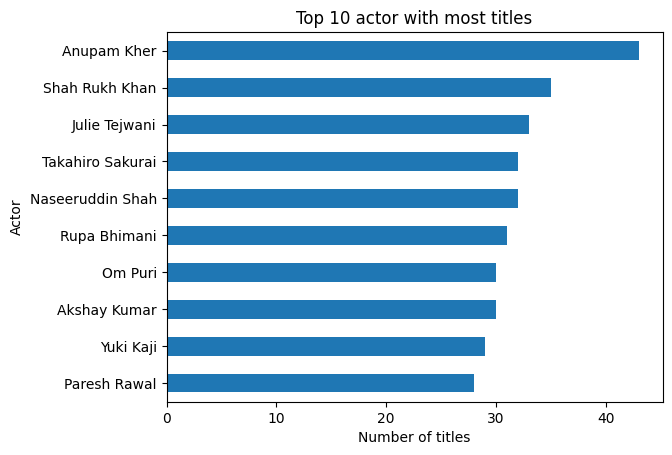

In [82]:
actor_count = title_cast['cast_member'].value_counts().head(10)
actor_count.sort_values().plot(kind='barh')

plt.title('Top 10 actor with most titles')
plt.xlabel('Number of titles')
plt.ylabel('Actor')
plt.show()

In [83]:
title_cast.duplicated(subset=['show_id','cast_member']).sum()

0

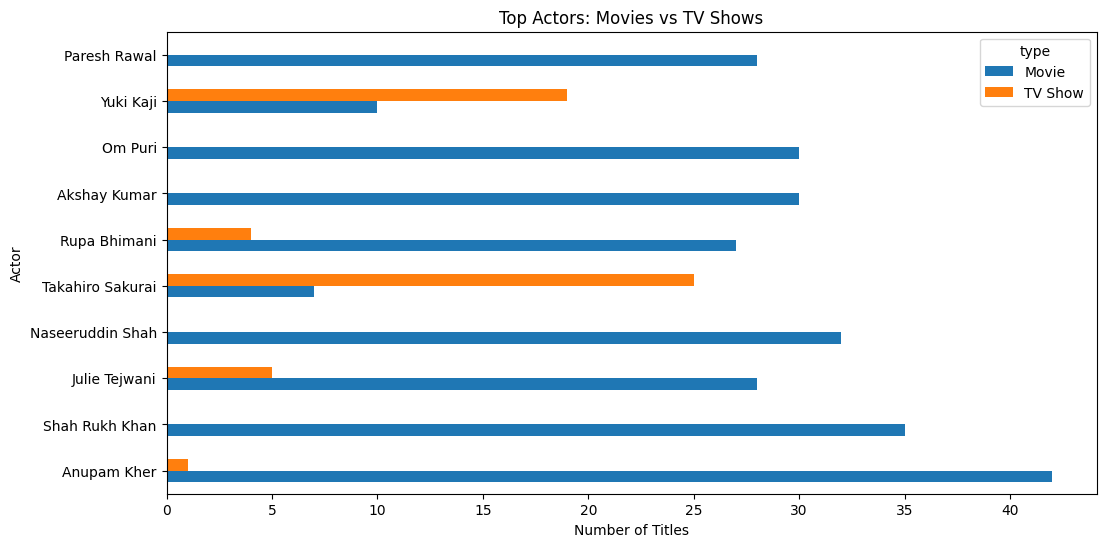

In [123]:
actor_type = title_cast.merge(df_clean[['show_id','type']],on='show_id',how='left')
actor_type

actor_type_table = pd.crosstab(actor_type['cast_member'],actor_type['type'])
top_actors = actor_count.head(10).index

actor_type_table.loc[top_actors].plot(kind='barh',figsize=(12,6))
plt.title('Top Actors: Movies vs TV Shows')
plt.ylabel('Actor')
plt.xlabel('Number of Titles')

plt.show()

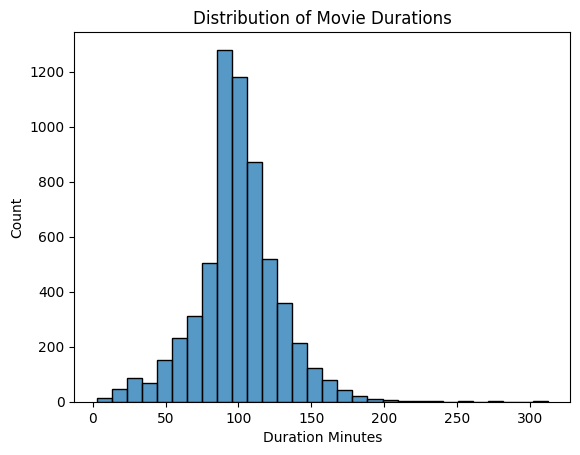

In [129]:
sns.histplot(data=df_clean,x='movie_duration_min',bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration Minutes')
plt.show()


<Axes: ylabel='movie_duration_min'>

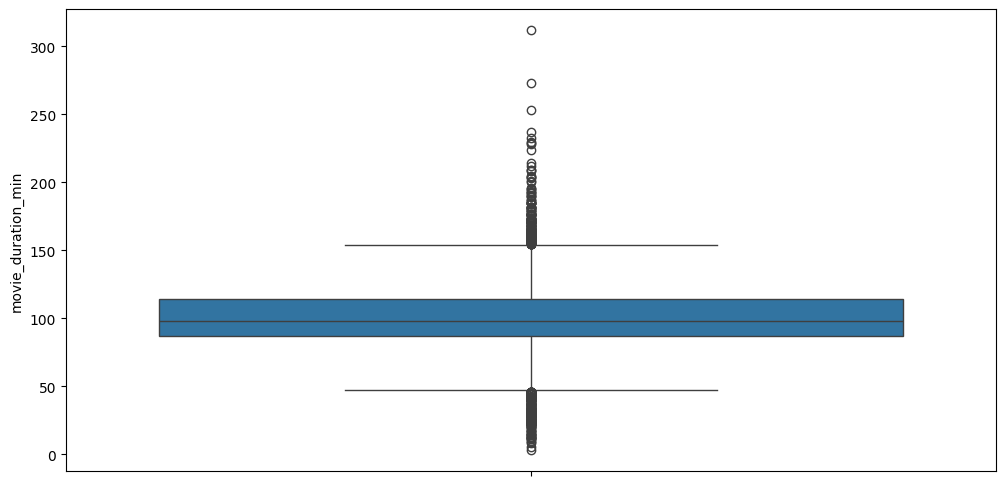

In [86]:
plt.figure(figsize=(12,6))
sns.boxplot(df_clean['movie_duration_min'])

Text(0.5, 1.0, 'Movie duration catgories')

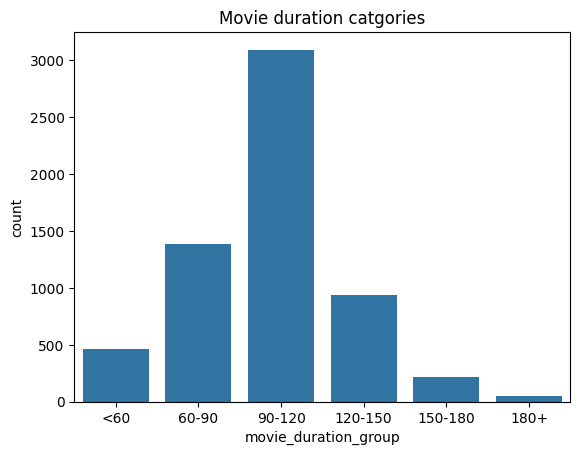

In [87]:
bins=[0,60,90,120,150,180,2000]
labels=['<60','60-90','90-120','120-150','150-180','180+']

df_clean['movie_duration_group'] = pd.cut(df_clean['movie_duration_min'],bins=bins,labels=labels,right=False)
#right=False [60,90) 90 goes to the next bin[90,120)
#rifht=True  [60,90) 90 goes into the same bin[60,90)
df_clean['movie_duration_group'].value_counts().index

sns.countplot(data=df_clean,x='movie_duration_group')
plt.title('Movie duration catgories')

In [88]:
#inter quartile range
movie_duration = df_clean[df_clean['type'] == 'Movie']['movie_duration_min'].dropna()

Q1 = movie_duration.quantile(0.25)
Q3 = movie_duration.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 87.0
Q3: 114.0
IQR: 27.0
Lower Bound: 46.5
Upper Bound: 154.5


In [ ]:
movie_outliers = movie_duration[
    (movie_duration < lower_bound) |
    (movie_duration > upper_bound)
]

print("Number of movie duration outliers:", len(movie_outliers))

print("Outlier percentage:",round(len(movie_outliers) / len(movie_duration) * 100, 2),"%")

Number of movie-duration outliers: 450
Outlier percentage: 7.34 %


movie_duration_min:

Q1 = 87 min, Q3 = 114 min, IQR = 27 min, so the "normal" 
movie band is 46.5–154.5 min. 450 movies (7.34%) fall 
outside that band — mostly very short stand-up 
specials/kids shorts on one end and epics on the other.

In [90]:
df_clean[
    (df_clean['type'] == 'Movie') &
    (
        (df_clean['movie_duration_min'] < lower_bound) |
        (df_clean['movie_duration_min'] > upper_bound)
    )
][
    ['title', 'release_year', 'movie_duration_min']
].sort_values(
    'movie_duration_min',
    ascending=False
).head(20)

#The detected extreme values were retained because they 
# may represent genuine differences in movie duration
#  rather than data-entry errors. Removing them could 
# distort the actual distribution of content duration.

,title,release_year,movie_duration_min
4253,Black Mirror: Bandersnatch,2018,312.0
717,Headspace: Unwind Your Mind,2021,273.0
2491,The School of Mischief,1973,253.0
2487,No Longer kids,1979,237.0
2484,Lock Your Girls In,1982,233.0
2488,Raya and Sakina,1984,230.0
166,Once Upon a Time in America,1984,229.0
7932,Sangam,1964,228.0
1019,Lagaan,2001,224.0
4573,Jodhaa Akbar,2008,214.0


In [91]:
nona_season = df_clean[df_clean['tv_seasons'].notna()]
nona_season['tv_seasons'].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: tv_seasons, dtype: float64

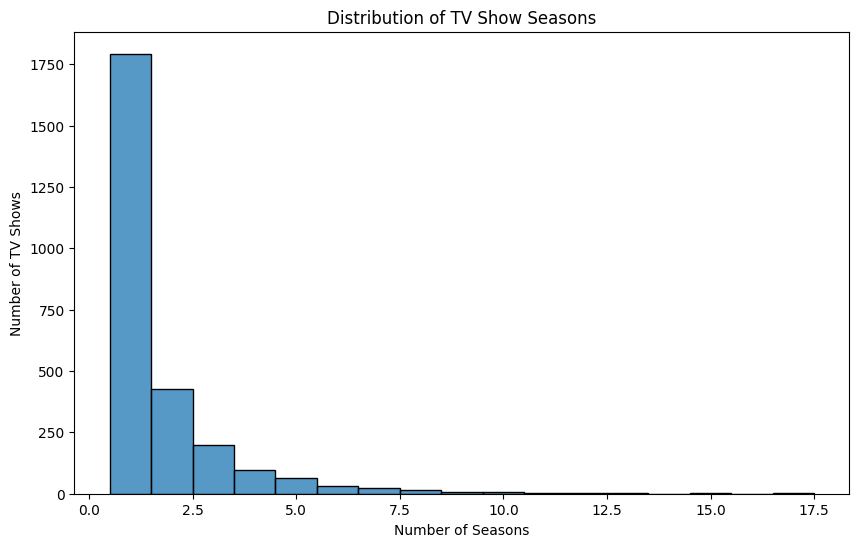

In [92]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=nona_season,
    x='tv_seasons',
    discrete=True
)

#data is right skewed
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.show()

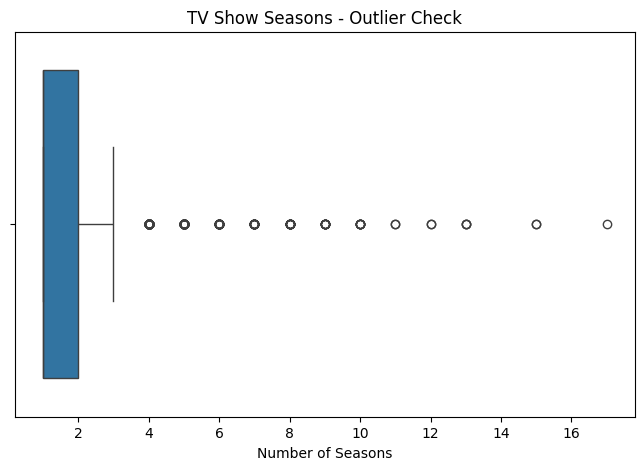

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=nona_season,
    x='tv_seasons'
)

plt.title('TV Show Seasons - Outlier Check')
plt.xlabel('Number of Seasons')

plt.show()

In [94]:
Q1 = nona_season['tv_seasons'].quantile(0.25)
Q3 = nona_season['tv_seasons'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

tv_outliers = nona_season[
    (nona_season['tv_seasons'] < lower) |
    (nona_season['tv_seasons'] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(tv_outliers))

Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower bound: -0.5
Upper bound: 3.5
Number of outliers: 259


tv_seasons:

Ranges 1–17, but median = 1 and mean = 1.76 — strongly right-skewed. 259 shows (9.68% of TV titles) are statistical outliers with 4+ seasons; the top of that list is *Grey's Anatomy* (17 seasons).

In [95]:
tv_outliers[['title', 'release_year', 'tv_seasons']].sort_values('tv_seasons',ascending=False).head(20)

,title,release_year,tv_seasons
548,Grey's Anatomy,2020,17.0
2423,Supernatural,2019,15.0
4798,NCIS,2017,15.0
1354,Heartland,2019,13.0
4220,COMEDIANS of the world,2019,13.0
7847,Red vs. Blue,2015,13.0
5412,Criminal Minds,2017,12.0
4964,Trailer Park Boys,2018,12.0
6456,Cheers,1992,11.0
6795,Frasier,2003,11.0


In [96]:
single_season_percentage = ((df_clean['tv_seasons'] == 1).sum() / df_clean['tv_seasons'].notna().sum()* 100)

print(single_season_percentage)

single_season = nona_season[nona_season['tv_seasons']==1.0]
single_season['tv_seasons'].shape[0]

67.00298953662183


1793

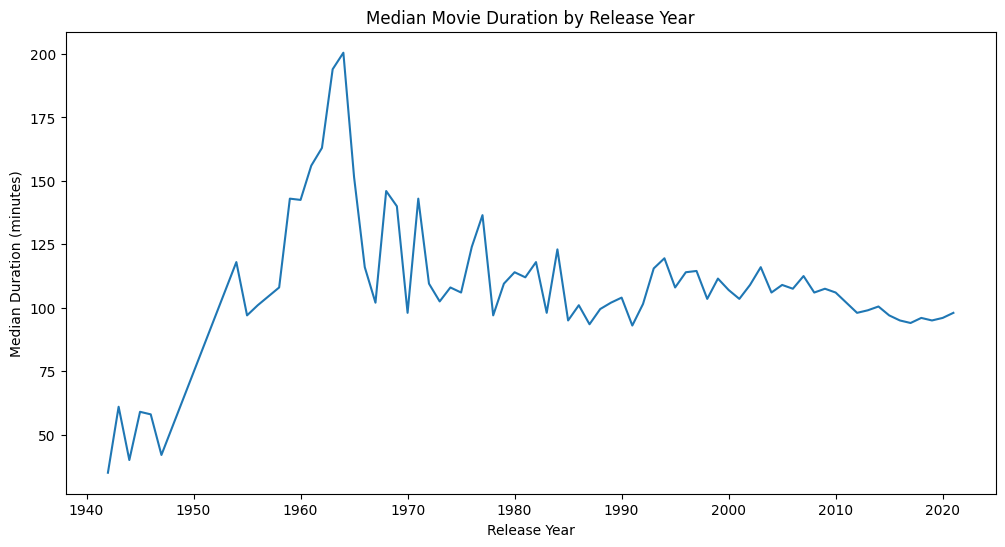

In [97]:
movie_duration_year = df_clean[df_clean['type']=='Movie'].groupby('release_year')['movie_duration_min'].median()
movie_duration_year

movie_duration_year.plot(
    figsize=(12, 6)
)

plt.title('Median Movie Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Median Duration (minutes)')

plt.show()

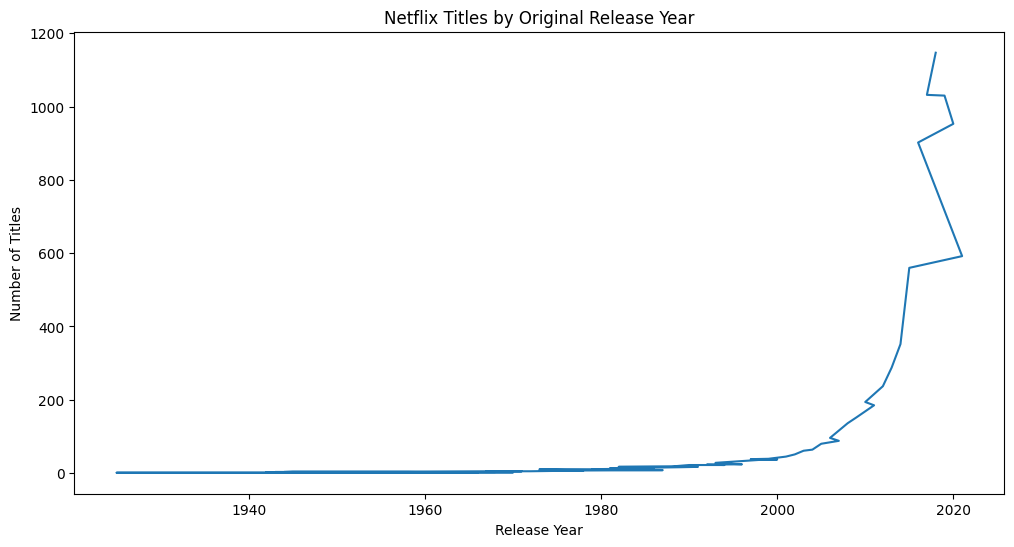

In [98]:
release_year_count = df_clean['release_year'].value_counts()
release_year_count

plt.figure(figsize=(12, 6))

release_year_count.plot(kind='line')

plt.title('Netflix Titles by Original Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

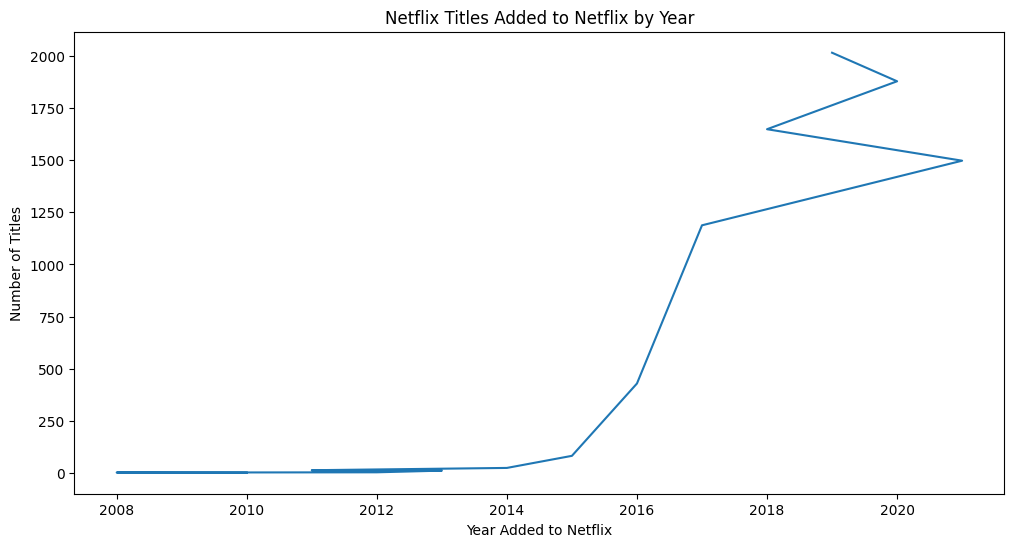

Peak title additions occurred in 2019.0 with 2016 titles.


In [99]:
added_year_count = (df_clean['added_year'].value_counts())

plt.figure(figsize=(12, 6))

added_year_count.plot(kind='line')

plt.title('Netflix Titles Added to Netflix by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')

plt.show()

peak_year = added_year_count.idxmax()
peak_count = added_year_count.max()

print(
    f"Peak title additions occurred in {peak_year} "
    f"with {peak_count} titles."
)

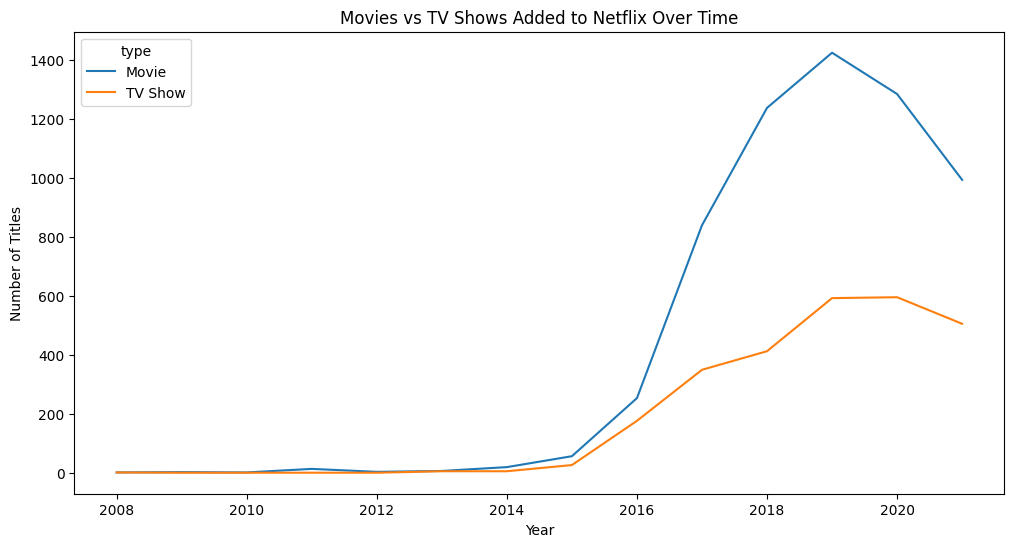

In [100]:
content_growth = pd.crosstab(df_clean['added_year'],df_clean['type'])
content_growth


content_growth.plot(kind='line',figsize=(12,6))

plt.title('Movies vs TV Shows Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

Text(0, 0.5, 'Percentage')

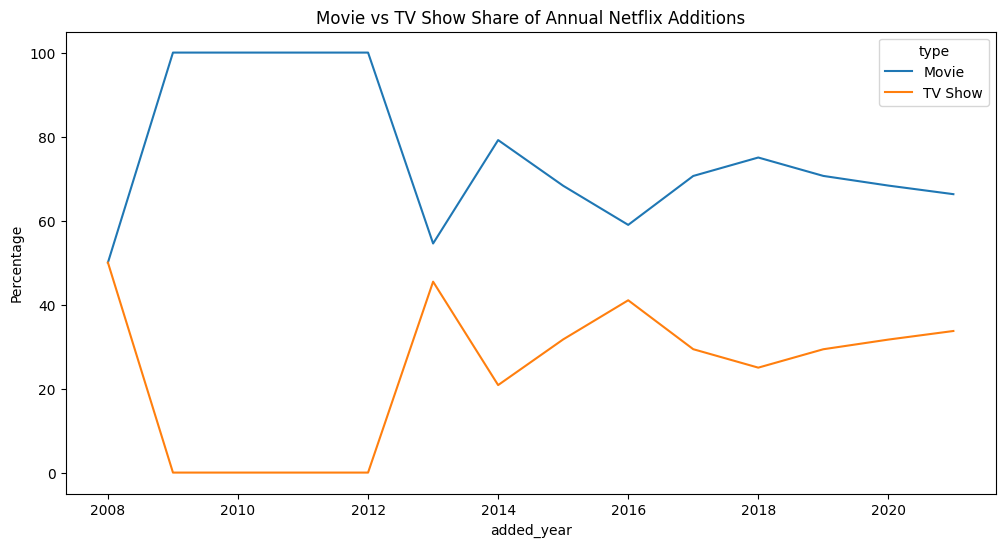

In [101]:
content_growth_pct = pd.crosstab(df_clean['added_year'],df_clean['type'],normalize='index')*100
content_growth_pct

content_growth_pct.plot(kind='line',figsize=(12,6))

plt.title('Movie vs TV Show Share of Annual Netflix Additions')
plt.ylabel('Percentage')

In [102]:
df_clean['content_age_when_added'] = (df_clean['added_year'] - df_clean['release_year'])
#Content added lesser than or equal to 5 years from the sub of added year and release year
df_clean['content_age_when_added'][df_clean['content_age_when_added'] <= 5.0].shape[0]

6673

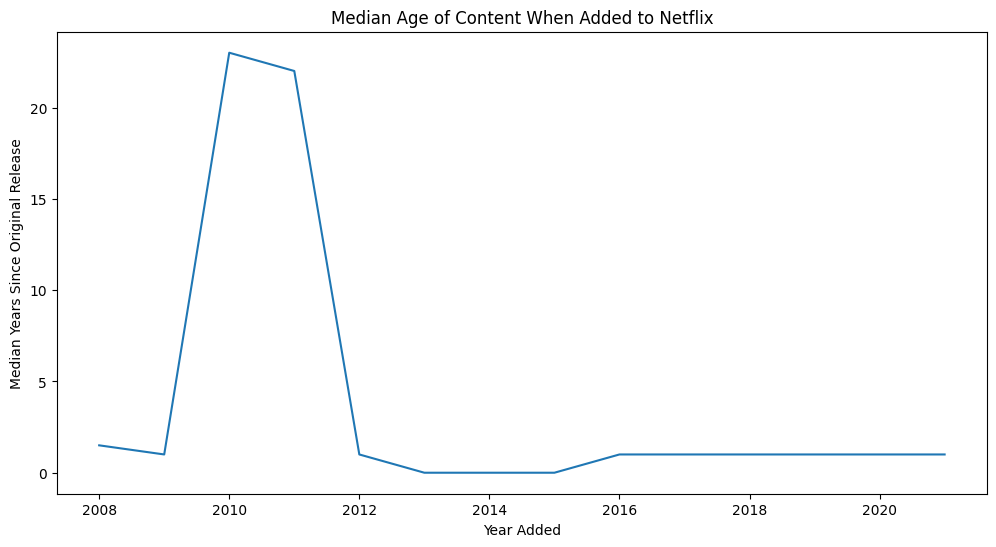

In [103]:
content_age_trend = (df_clean.groupby('added_year')['content_age_when_added'].median())
content_age_trend

content_age_trend.plot(
    figsize=(12, 6)
)

plt.title('Median Age of Content When Added to Netflix')
plt.xlabel('Year Added')
plt.ylabel('Median Years Since Original Release')

plt.show()

In [104]:
(df_clean['content_age_when_added'] < 0).sum()

df_clean[
    df_clean['content_age_when_added'] < 0
][[
    'title',
    'release_year',
    'added_year',
    'content_age_when_added'
]]

,title,release_year,added_year,content_age_when_added
1551,Hilda,2021,2020.0,-1.0
1696,Polly Pocket,2021,2020.0,-1.0
2920,Love Is Blind,2021,2020.0,-1.0
3168,Fuller House,2020,2019.0,-1.0
3287,Maradona in Mexico,2020,2019.0,-1.0
3369,BoJack Horseman,2020,2019.0,-1.0
3433,The Hook Up Plan,2020,2019.0,-1.0
4844,Unbreakable Kimmy Schmidt,2019,2018.0,-1.0
4845,Arrested Development,2019,2018.0,-1.0
5394,Hans Teeuwen: Real Rancour,2018,2017.0,-1.0


content_age_when_added:

(added_year − release_year): Mostly small and positive (75.77% of the catalog, 6,673 of 8,807 titles, was added within 5 years of release), with a handful of negative values (title added the same year listed as its release year, a data-labeling quirk rather than a real "added before release" event).

C:\Users\GOKUL\AppData\Local\Temp\ipykernel_1700\372015044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  release_type = (df_clean.groupby('type')['release_year'].median())


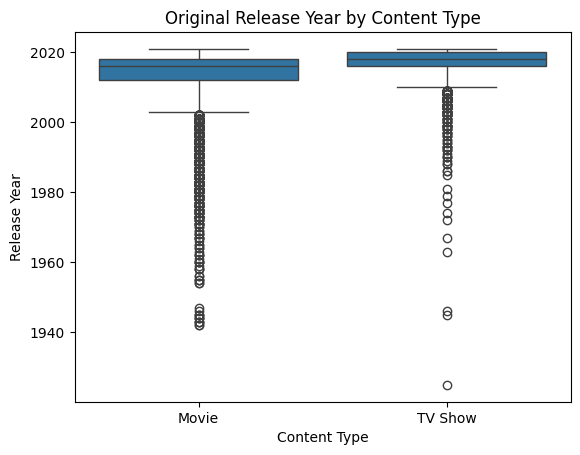

In [105]:
release_type = (df_clean.groupby('type')['release_year'].median())
release_type

sns.boxplot(data=df_clean,x='type',y='release_year')

plt.title('Original Release Year by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Release Year')

plt.show()

In [106]:
top5_countries = (
    title_country['country']
    .value_counts()
    .head(5)
    .index
)

top5_genres = (
    title_genre['genre']
    .value_counts()
    .head(5)
    .index
)

country_genre = title_country.merge(
    title_genre[['show_id', 'genre']],
    on='show_id',
    how='inner'
)

cg = country_genre[country_genre['country'].isin(top5_countries) & country_genre['genre'].isin(top5_genres)]

country_genre_table = pd.crosstab(cg['country'],cg['genre'])
country_genre_table

genre,Comedies,Documentaries,Dramas,International Movies,International TV Shows
country,,,,,
Canada,94,42,82,60,25
France,51,44,167,207,43
India,323,27,662,864,66
United Kingdom,91,128,197,170,128
United States,680,512,835,166,74


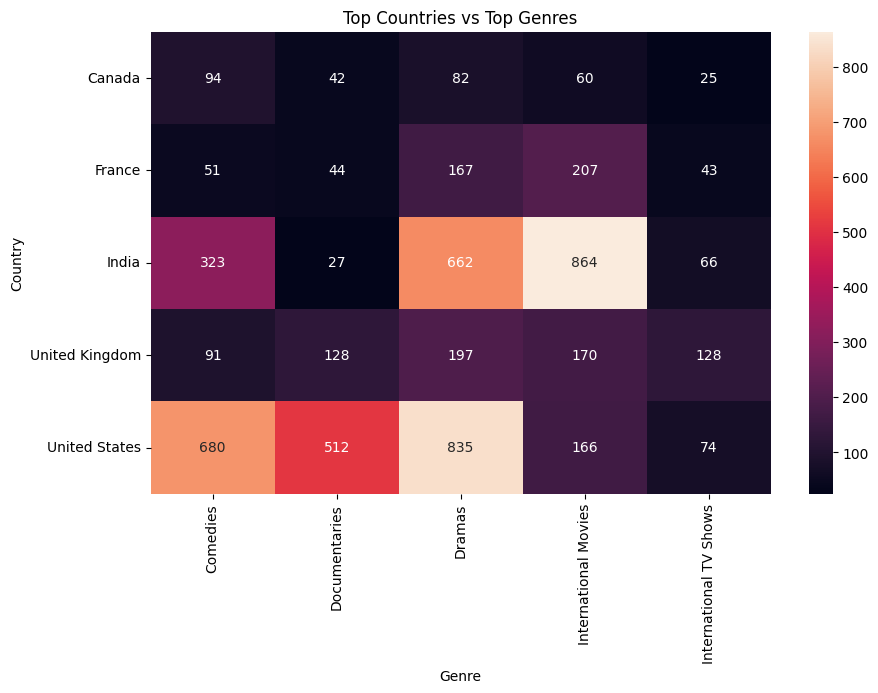

In [107]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    country_genre_table,
    annot=True,
    fmt='d'
)

plt.title('Top Countries vs Top Genres')
plt.xlabel('Genre')
plt.ylabel('Country')

plt.show()

Business Insights

Patterns observed in the data, and what they imply for Netflix's content strategy:

1. **The catalog is Movie-heavy (69.62%) in a TV-Show-driven streaming era.** Movies outnumber TV Shows more than 2:1 by title count. Since binge-worthy series are widely understood to drive subscriber retention and watch-time, a catalog this skewed toward one-off movies may be under-leveraging the format that keeps people subscribed month over month.

2. **Content addition growth reversed after 2019.** Additions rose every year through 2019 (peak: 2,016 titles) then fell in 2020 (1,879) and again in 2021 (1,498). This lines up with the period when Netflix faced production slowdowns (COVID-19) and a wave of new competitors (Disney+, HBO Max, Apple TV+) entering the market — the data reflects a catalog-growth strategy under real pressure, not steady expansion.

3. **67% of TV Shows never get past season 1**, and only 9.68% reach 4+ seasons. This is either (a) a deliberate low-risk strategy — greenlight cheaply, cancel fast, keep only proven winners — or (b) a retention risk, since viewers who latch onto a new show have a two-in-three chance it won't be renewed. Either way, it's a structural feature of the platform worth flagging to stakeholders.

4. **The library is US-anchored (36.83%) with India as a clear #2 (10.44%)** and a long tail of 60+ countries contributing marginally. This matches Netflix's known strategy of prioritizing large, high-growth international markets (India, South Korea, etc.) rather than spreading investment evenly — but it also means most countries are barely represented, which limits genuinely localized content in most of the world.

5. **The catalog skews toward mature audiences.** TV-MA and TV-14 together cover well over 60% of all titles, and family-friendly ratings (G, PG, TV-G, TV-Y) are a small minority. This narrows the appeal for households actively choosing a platform for kids/family content, a segment competitors (Disney+) target directly.

6. **Content is mostly recent when added (75.77% within 5 years of release)**, meaning Netflix leans on fresh licensing and originals over building a deep back-catalog. This keeps the platform feeling current but leaves a smaller "classic library" advantage compared to services that hold long-term rights to older franchises.

7. **Genre supply is concentrated in a few broad, internationally-portable categories** — International Movies and Dramas alone account for over 5,100 genre-tags combined, out of 42 total genres. This is efficient for global licensing but risks genre-fatigue and under-serves niche-genre audiences.

8. **No single director or actor anchors the catalog** (top contributors appear in only ~15–22 titles out of 8,807). Netflix's content strategy is breadth-of-catalog driven, not built around exclusive deals with a small number of marquee names — different from a traditional studio-led content strategy.


Recommendations


1. **Add more TV series relative to movies.** The catalog is currently 70% movies. Shifting new investment toward multi-season shows can help increase how long people stay subscribed.

2. **Figure out why 2 out of 3 shows stop after one season, and fix it if it's hurting retention.** If it's an intentional cost-saving move, keep doing it. If good shows are being cancelled too early, consider committing to more second seasons for shows that test well with viewers.

3. **Grow content in already-strong international markets (like India and South Korea) instead of spreading investment thin across many small markets.** These regions are already showing strong contribution numbers — doubling down is lower-risk than starting from scratch elsewhere.

4. **Add more family-friendly and kids' content.** Less than 10% of the catalog is rated for general/family audiences. This is a straightforward gap versus competitors who market heavily to families.

5. **Fix the missing information in the catalog data.** Nearly 30% of titles are missing a listed director, and about 9% are missing cast or country information. Clean, complete data directly improves how well "Recommended for You" and search work for viewers.

6. **Set a clear target to reverse the drop in new titles added each year since 2019.** Whether the cause is budget, production delays, or competition, leadership should decide on a specific number of new titles to add next year and track progress against it monthly.

7. **Rebalance the mix of mature vs. family content over time**, tracking the ratio quarterly so it doesn't drift further toward mature-only audiences and risk losing family subscribers to competitors.

8. **Use the country-genre patterns to guide regional content commissioning** — invest in the genres that already work well in each region (e.g., Dramas and International Movies in India) rather than applying a one-size-fits-all genre strategy worldwide.
